In [60]:
import pandas as pd
import re

_CLEAN_RE = re.compile(r"[^A-Za-z\s]+")   # non-letters 

def parse_text(df):
    return df.str.replace(_CLEAN_RE, "", regex=True)

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

fake["label"] = 0   # Fake
real["label"] = 1   # Real

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df["text"] = df["title"]# + " " + df["text"]
# df["text"] = parse_text(df["text"])

tit_len = df["title"].map(lambda x: len(x))
df = df[["text", "label"]]

print(df)

                                                    text  label
0      Ben Stein Calls Out 9th Circuit Court: Committ...      0
1      Trump drops Steve Bannon from National Securit...      1
2      Puerto Rico expects U.S. to lift Jones Act shi...      1
3       OOPS: Trump Just Accidentally Confirmed He Le...      0
4      Donald Trump heads for Scotland to reopen a go...      1
...                                                  ...    ...
44893  UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...      0
44894  PM May seeks to ease Japan's Brexit fears duri...      1
44895  Merkel: Difficult German coalition talks can r...      1
44896   Trump Stole An Idea From North Korean Propaga...      0
44897  BREAKING: HILLARY CLINTON’S STATE DEPARTMENT G...      0

[44898 rows x 2 columns]


In [55]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [56]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [57]:
import numpy as np

def _to_list_of_str(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        return [texts]

    return ["" if t is None else str(t) for t in texts]

def tokenize(texts):
    texts = _to_list_of_str(texts)
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

def predict(texts):
    texts = _to_list_of_str(texts)
    with torch.no_grad():
        inputs = tokenize(texts)
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()

def predict_tokens(tokens):
    with torch.no_grad():
        outputs = model(**tokens)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    return probs

In [58]:
import torch
import numpy as np
from tqdm import tqdm

def batch_encodings(test_encodings, first, last):
    batch_input_ids = test_encodings['input_ids'][first:last]
    batch_attention_mask = test_encodings['attention_mask'][first:last]
    batch_token_type_ids = test_encodings['token_type_ids'][first:last]

    return {
        'input_ids': batch_input_ids,
        'attention_mask': batch_attention_mask,
        'token_type_ids': batch_token_type_ids
    }

TEST_N_BATCHES = 8

test_encodings = tokenize(test_texts)
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

batch_size = 16 
test_labels = test_labels[:TEST_N_BATCHES * batch_size]

# Define a batch size for inference to prevent OutOfMemory errors
predictions = []

# Get the total number of test samples
num_samples = test_encodings['input_ids'].shape[0]

with torch.no_grad():
    # for i in tqdm(range(0, num_samples, batch_size)):
    for i in tqdm(range(0, batch_size * TEST_N_BATCHES, batch_size)):
        # Extract batch from test_encodings
        batch = batch_encodings(test_encodings, i, i + batch_size)

        # Perform inference on the batch
        outputs = model(**batch)
        batch_predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_predictions)

# Convert the list of predictions to a numpy array
predictions = np.array(predictions)

100%|██████████| 8/8 [00:06<00:00,  1.30it/s]


In [59]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}\n")
print(classification_report(test_labels, predictions, target_names=["Fake", "Real"]))

Test Accuracy: 0.6562

              precision    recall  f1-score   support

        Fake       0.58      1.00      0.74        62
        Real       1.00      0.33      0.50        66

    accuracy                           0.66       128
   macro avg       0.79      0.67      0.62       128
weighted avg       0.80      0.66      0.62       128



In [26]:
import shap

BG_N = 100

background_texts = pd.concat([
    fake.sample(BG_N, random_state=42),
    real.sample(BG_N, random_state=42)
])['text'].dropna().tolist()

In [ ]:
eval_texts = df['text'].dropna().tolist()[:2]
print(eval_texts)

# masker = shap.maskers.Text(
#     tokenizer=tokenizer,  
#     mask_token=tokenizer.mask_token,
# )

masker = shap.maskers.Text(
    tokenizer=None,  
)

explainer = shap.Explainer(predict, masker, output_names=['fake', 'real'])
shap_values = explainer(eval_texts)

['Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Or

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:48, 24.27s/it]               


In [ ]:
print(shap_values)

.values =
array([array([[ 6.91066768e-03, -6.91066577e-03],
              [ 1.27282651e-02, -1.27282633e-02],
              [-2.42525263e-04,  2.42526048e-04],
              [-2.42525263e-04,  2.42526048e-04],
              [ 2.50467924e-03, -2.50467834e-03],
              [ 2.85876482e-03, -2.85876276e-03],
              [ 1.48163150e-02, -1.48163144e-02],
              [ 4.15343522e-03, -4.15343597e-03],
              [-8.22132030e-03,  8.22132006e-03],
              [-7.82501461e-03,  7.82501407e-03],
              [-1.02626570e-02,  1.02626568e-02],
              [-1.82544504e-02,  1.82544495e-02],
              [ 2.97359348e-04, -2.97358746e-04],
              [ 2.97359348e-04, -2.97358746e-04],
              [ 2.18322212e-05, -2.18318521e-05],
              [ 2.18322212e-05, -2.18318521e-05],
              [ 3.84650014e-03, -3.84650094e-03],
              [ 2.62789669e-03, -2.62789727e-03],
              [ 1.90701041e-03, -1.90700996e-03],
              [ 1.90701041e-03, -1.90700

In [61]:
def top_words(shap_values, n=1, sample_idx=0, class_idx=0, top_k=10):
    dfs = []

    for sample_idx in range(n):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        df = pd.DataFrame({
            "token": tokens,
            "importance": values
        })

        df = df[df.token.str.strip() != ""]
        df["abs"] = df.importance.abs()

        dfs.append(df.sort_values("abs", ascending=False).head(top_k))

    return dfs

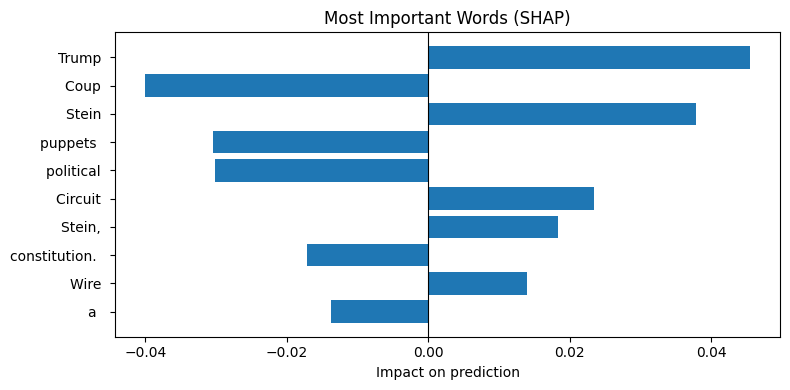

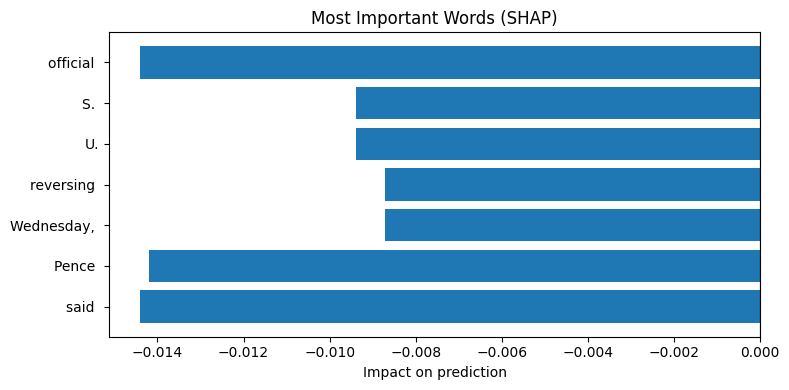

In [62]:
import matplotlib.pyplot as plt

def plot_top_words(dfs):
    for i in range(len(dfs)):
        plt.figure(figsize=(8, 4))
        plt.barh(
            dfs[i].token[::-1],
            dfs[i].importance[::-1]
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title("Most Important Words (SHAP)")
        plt.xlabel("Impact on prediction")
        plt.tight_layout()
        plt.show()

plot_top_words(top_words(shap_values, 2))

In [52]:
texts = eval_texts
for _ in tqdm(range(10)):
    print(predict(eval_texts))
    shap_values = explainer(texts)
    for i in range(2):
        values = shap_values.values[i].T[i]
        words = shap_values.data[i]
        print(values.shape, words.shape)
        most_influential = np.argmax(values)
        print(i, words[most_influential])
        new_words = np.concat([words[:most_influential], words[most_influential + 1:]])
        new_text = ''.join(new_words)
        texts[i] = new_text

[[9.9970251e-01 2.9750683e-04]
 [1.3801410e-04 9.9986196e-01]]


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 3it [00:49, 24.68s/it]


(176,) (176,)
0 Court: 
(804,) (804,)
1 said, 
[[9.9968660e-01 3.1338091e-04]
 [1.3801410e-04 9.9986196e-01]]


...

(168,) (168,)
0 TRUMP 
(796,) (796,)
1 said 
[[9.9971360e-01 2.8632808e-04]
 [1.4157365e-04 9.9985838e-01]]


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 3it [00:50, 25.44s/it]
100%|██████████| 10/10 [08:32<00:00, 51.27s/it]

(167,) (167,)
0 Trump 
(795,) (795,)
1 official 


In [53]:
predict(texts)

array([[9.9969256e-01, 3.0742781e-04],
       [1.4230709e-04, 9.9985766e-01]], dtype=float32)